In [18]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              confusion_matrix, classification_report, roc_auc_score)

from imblearn.over_sampling import SMOTE
# Plot style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (8, 5)

# For reproducibility
RANDOM_STATE = 42

In [19]:
df = pd.read_csv('heart_failure_clinical_records_dataset.csv')

print("Shape of dataset (rows, columns):", df.shape)
print("\nColumn dtypes:\n", df.dtypes)
print("\nMissing values:\n", df.isnull().sum())
df.head()

Shape of dataset (rows, columns): (299, 13)

Column dtypes:
 age                         float64
anaemia                       int64
creatinine_phosphokinase      int64
diabetes                      int64
ejection_fraction             int64
high_blood_pressure           int64
platelets                   float64
serum_creatinine            float64
serum_sodium                  int64
sex                           int64
smoking                       int64
time                          int64
DEATH_EVENT                   int64
dtype: object

Missing values:
 age                         0
anaemia                     0
creatinine_phosphokinase    0
diabetes                    0
ejection_fraction           0
high_blood_pressure         0
platelets                   0
serum_creatinine            0
serum_sodium                0
sex                         0
smoking                     0
time                        0
DEATH_EVENT                 0
dtype: int64


,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
0,75.0,0,582,0,20,1,265000.00,1.9,130,1,0,4,1
1,55.0,0,7861,0,38,0,263358.03,1.1,136,1,0,6,1
2,65.0,0,146,0,20,0,162000.00,1.3,129,1,1,7,1
3,50.0,1,111,0,20,0,210000.00,1.9,137,1,0,7,1
4,65.0,1,160,1,20,0,327000.00,2.7,116,0,0,8,1


In [20]:
# Statistical summary of numeric columns
df.describe().T


,count,mean,std,min,25%,50%,75%,max
age,299.0,60.833893,11.894809,40.0,51.0,60.0,70.0,95.0
anaemia,299.0,0.431438,0.496107,0.0,0.0,0.0,1.0,1.0
creatinine_phosphokinase,299.0,581.839465,970.287881,23.0,116.5,250.0,582.0,7861.0
diabetes,299.0,0.418060,0.494067,0.0,0.0,0.0,1.0,1.0
ejection_fraction,299.0,38.083612,11.834841,14.0,30.0,38.0,45.0,80.0
high_blood_pressure,299.0,0.351171,0.478136,0.0,0.0,0.0,1.0,1.0
platelets,299.0,263358.029264,97804.236869,25100.0,212500.0,262000.0,303500.0,850000.0
serum_creatinine,299.0,1.393880,1.034510,0.5,0.9,1.1,1.4,9.4
serum_sodium,299.0,136.625418,4.412477,113.0,134.0,137.0,140.0,148.0
sex,299.0,0.648829,0.478136,0.0,0.0,1.0,1.0,1.0


In [21]:
TARGET = 'DEATH_EVENT'

# Check target class distribution (needed later to detect imbalance)
print(df[TARGET].value_counts())
print("\nClass proportion (%):")
print(df[TARGET].value_counts(normalize=True) * 100)

DEATH_EVENT
0    203
1     96
Name: count, dtype: int64

Class proportion (%):
DEATH_EVENT
0    67.892977
1    32.107023
Name: proportion, dtype: float64


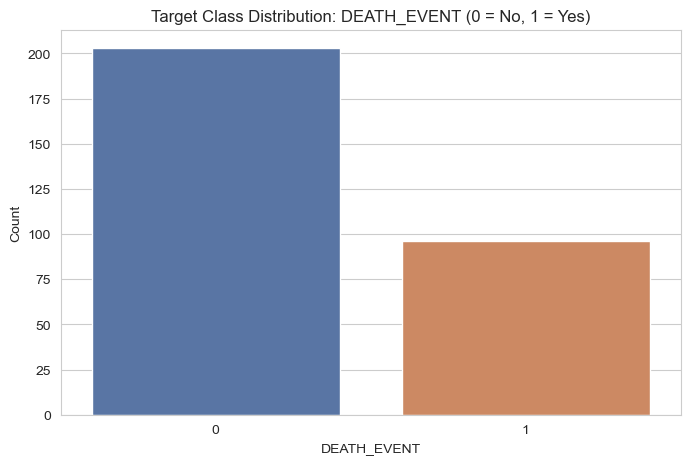

In [22]:
# Visualize target class distribution
plt.figure()
sns.countplot(x=TARGET, data=df, palette=['#4C72B0', '#DD8452'])
plt.title('Target Class Distribution: DEATH_EVENT (0 = No, 1 = Yes)')
plt.xlabel('DEATH_EVENT')
plt.ylabel('Count')
plt.show()

In [23]:
X = df.drop(columns=[TARGET])
y = df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print("Train shape:", X_train.shape, " Test shape:", X_test.shape)
print("Train class balance:\n", y_train.value_counts(normalize=True))
print("Test class balance:\n", y_test.value_counts(normalize=True))

Train shape: (239, 12)  Test shape: (60, 12)
Train class balance:
 DEATH_EVENT
0    0.677824
1    0.322176
Name: proportion, dtype: float64
Test class balance:
 DEATH_EVENT
0    0.683333
1    0.316667
Name: proportion, dtype: float64


In [24]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)   # fit + transform on train
X_test_scaled = scaler.transform(X_test)          # transform ONLY on test

# Convert back to DataFrame for readability
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)

X_train_scaled.head()

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time
115,-0.269050,1.110696,-0.200735,-0.900337,0.176528,-0.770281,-1.004722,-0.360437,0.559915,-1.333818,-0.682831,-0.467847
23,-0.706883,-0.900337,-0.534318,1.110696,1.847425,-0.770281,1.051685,-0.544467,-0.345802,0.749728,-0.682831,-1.359167
0,1.219579,-0.900337,-0.020580,-0.900337,-1.494369,1.298227,0.013401,0.467698,-1.477949,0.749728,-0.682831,-1.591685
247,0.256348,-0.900337,-0.455129,-0.900337,-1.076645,-0.770281,-0.178127,0.927773,-0.345802,0.749728,-0.682831,1.121028
194,-1.407414,-0.900337,-0.020580,-0.900337,-1.494369,1.298227,-1.387778,0.191653,-0.345802,0.749728,-0.682831,0.681827


In [25]:
print("Before SMOTE:", y_train.value_counts().to_dict())

smote = SMOTE(random_state=RANDOM_STATE)
X_train_bal, y_train_bal = smote.fit_resample(X_train_scaled, y_train)

print("After SMOTE :", y_train_bal.value_counts().to_dict())

Before SMOTE: {0: 162, 1: 77}
After SMOTE : {0: 162, 1: 162}


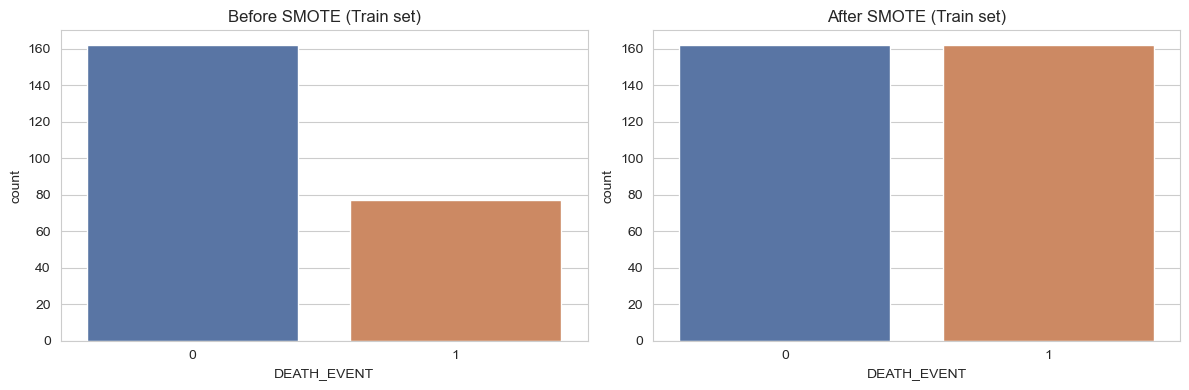

In [26]:
# Visual comparison of class distribution before/after SMOTE
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.countplot(x=y_train, ax=axes[0], palette=['#4C72B0', '#DD8452'])
axes[0].set_title('Before SMOTE (Train set)')
sns.countplot(x=y_train_bal, ax=axes[1], palette=['#4C72B0', '#DD8452'])
axes[1].set_title('After SMOTE (Train set)')
plt.tight_layout()
plt.show()

In [27]:
# Dictionary of models to train and compare
models = {
    'Logistic Regression': LogisticRegression(random_state=RANDOM_STATE, max_iter=1000),
    'Decision Tree': DecisionTreeClassifier(random_state=RANDOM_STATE),
    'Random Forest': RandomForestClassifier(random_state=RANDOM_STATE, n_estimators=200),
    'KNN': KNeighborsClassifier(n_neighbors=5),
    'SVM': SVC(random_state=RANDOM_STATE, probability=True),
    'Naive Bayes': GaussianNB(),
    'Gradient Boosting': GradientBoostingClassifier(random_state=RANDOM_STATE)
}

results = []          # store metric summary for comparison table
trained_models = {}   # keep fitted models for later (confusion matrix, tuning, etc.)

for name, model in models.items():
    # Train on the SMOTE-balanced, scaled training data
    model.fit(X_train_bal, y_train_bal)
    trained_models[name] = model

    # Predict on the untouched test set
    y_pred = model.predict(X_test_scaled)

    # Compute evaluation metrics
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    results.append({'Model': name, 'Accuracy': acc, 'Precision': prec,
                     'Recall': rec, 'F1-Score': f1})

results_df = pd.DataFrame(results).sort_values('F1-Score', ascending=False).reset_index(drop=True)
results_df

,Model,Accuracy,Precision,Recall,F1-Score
0,Gradient Boosting,0.800000,0.666667,0.736842,0.700000
1,Decision Tree,0.783333,0.625000,0.789474,0.697674
2,Random Forest,0.800000,0.684211,0.684211,0.684211
3,Logistic Regression,0.800000,0.733333,0.578947,0.647059
4,KNN,0.750000,0.611111,0.578947,0.594595
5,Naive Bayes,0.750000,0.625000,0.526316,0.571429
6,SVM,0.733333,0.588235,0.526316,0.555556


===== Logistic Regression =====
              precision    recall  f1-score   support

      No (0)       0.82      0.90      0.86        41
         (1)       0.73      0.58      0.65        19

    accuracy                           0.80        60
   macro avg       0.78      0.74      0.75        60
weighted avg       0.79      0.80      0.79        60

===== Decision Tree =====
              precision    recall  f1-score   support

      No (0)       0.89      0.78      0.83        41
         (1)       0.62      0.79      0.70        19

    accuracy                           0.78        60
   macro avg       0.76      0.78      0.76        60
weighted avg       0.81      0.78      0.79        60

===== Random Forest =====
              precision    recall  f1-score   support

      No (0)       0.85      0.85      0.85        41
         (1)       0.68      0.68      0.68        19

    accuracy                           0.80        60
   macro avg       0.77      0.77      0.77 

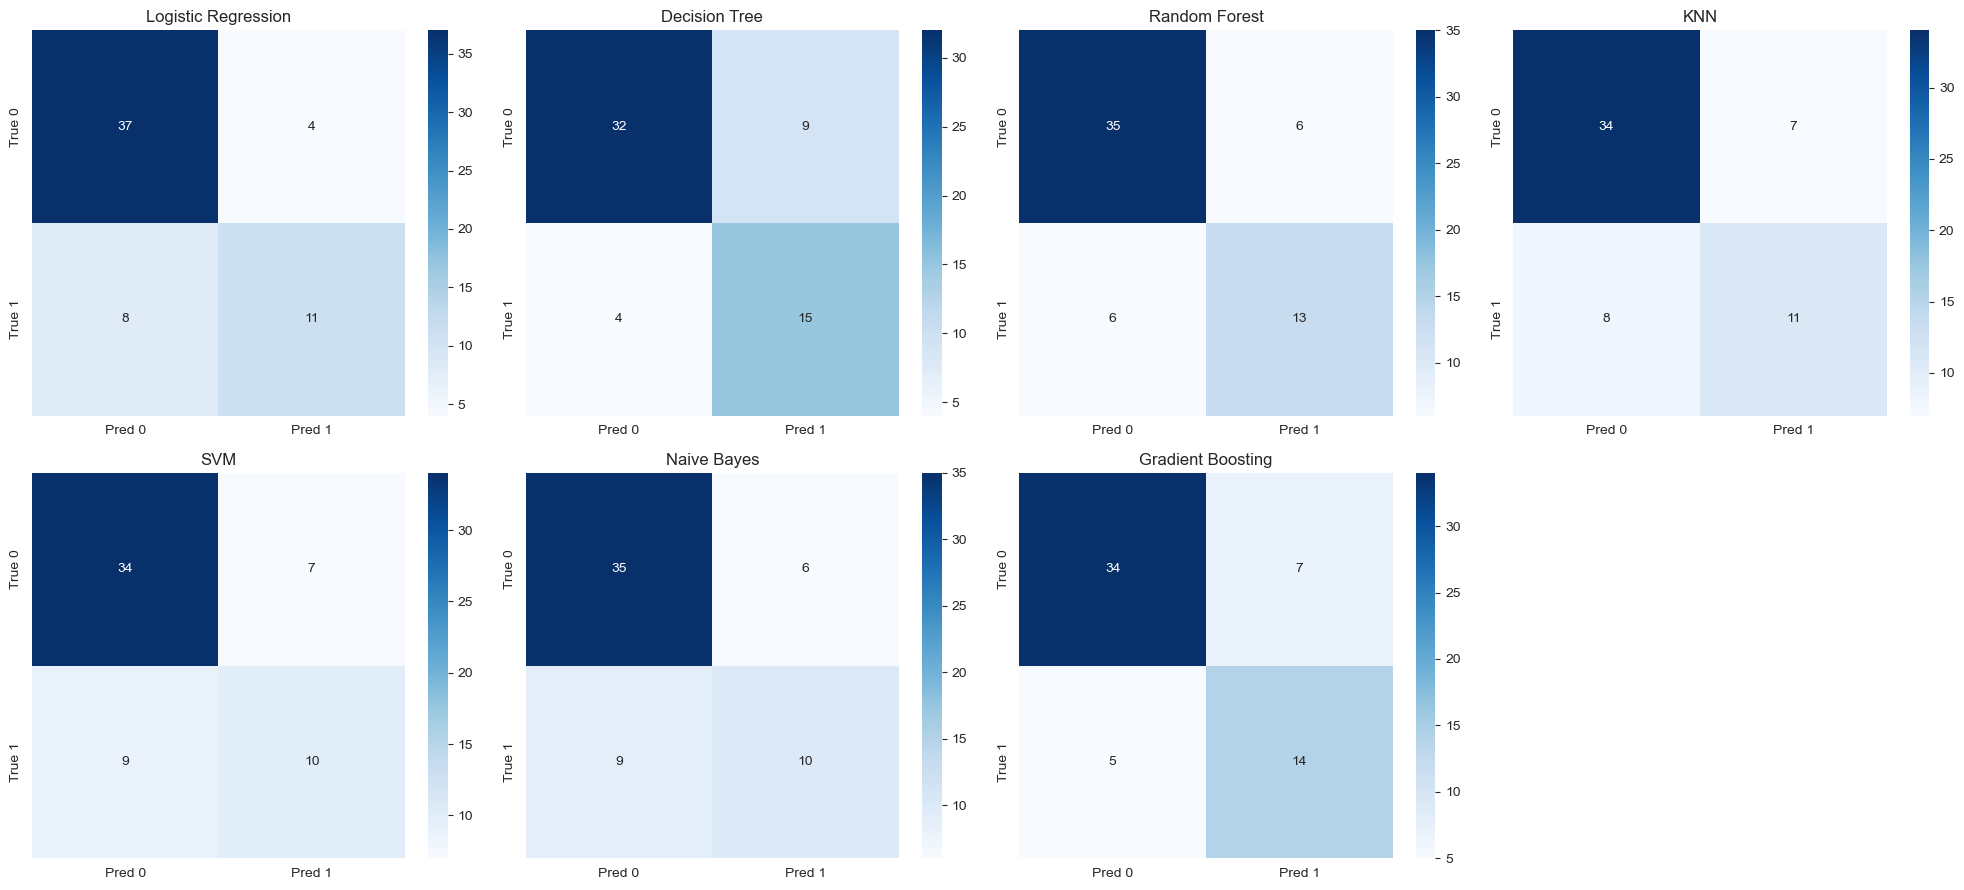

In [28]:
fig, axes = plt.subplots(2, 4, figsize=(20, 9))
axes = axes.flatten()

for i, (name, model) in enumerate(trained_models.items()):
    y_pred = model.predict(X_test_scaled)

    print(f"===== {name} =====")
    print(classification_report(y_test, y_pred, target_names=['No (0)', '(1)']))

    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i],
                xticklabels=['Pred 0', 'Pred 1'], yticklabels=['True 0', 'True 1'])
    axes[i].set_title(name)

# Hide any unused subplot axes
for j in range(len(trained_models), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

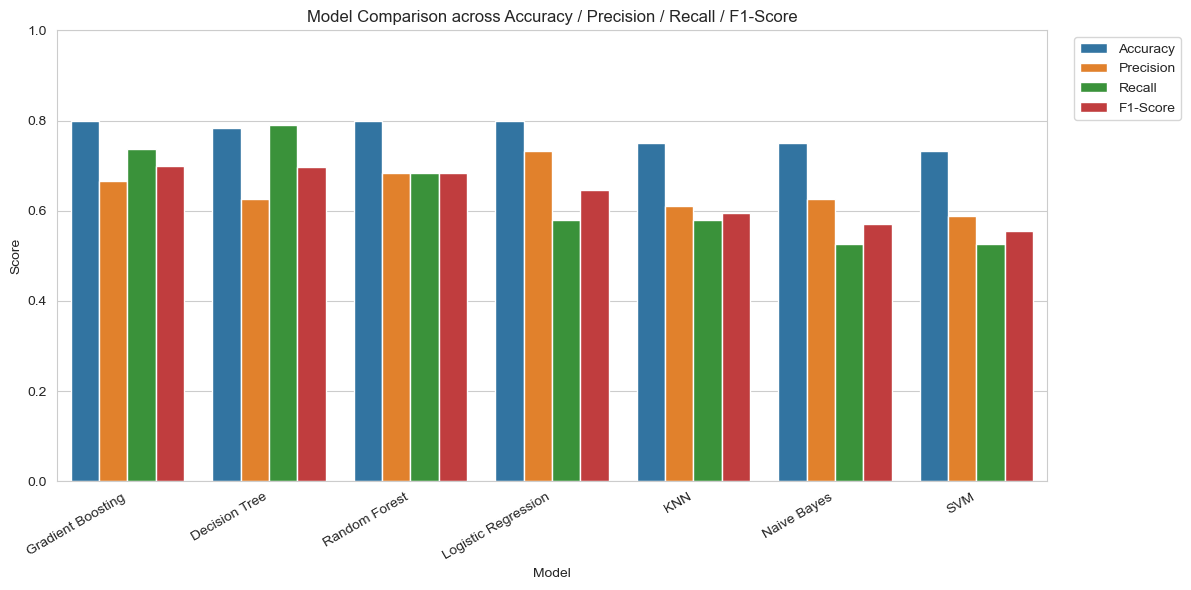

,Model,Accuracy,Precision,Recall,F1-Score
0,Gradient Boosting,0.800000,0.666667,0.736842,0.700000
1,Decision Tree,0.783333,0.625000,0.789474,0.697674
2,Random Forest,0.800000,0.684211,0.684211,0.684211
3,Logistic Regression,0.800000,0.733333,0.578947,0.647059
4,KNN,0.750000,0.611111,0.578947,0.594595
5,Naive Bayes,0.750000,0.625000,0.526316,0.571429
6,SVM,0.733333,0.588235,0.526316,0.555556


In [29]:
# Bar chart comparing all models across the 4 key metrics
results_melted = results_df.melt(id_vars='Model', var_name='Metric', value_name='Score')

plt.figure(figsize=(12, 6))
sns.barplot(data=results_melted, x='Model', y='Score', hue='Metric')
plt.xticks(rotation=30, ha='right')
plt.title('Model Comparison across Accuracy / Precision / Recall / F1-Score')
plt.ylim(0, 1)
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

results_df

In [30]:
# Automatically pick the best model based on F1-Score
best_model_name = results_df.iloc[0]['Model']
print(f"Best performing model (by F1-Score): {best_model_name}")
print(results_df.iloc[0])

Best performing model (by F1-Score): Gradient Boosting
Model        Gradient Boosting
Accuracy                   0.8
Precision             0.666667
Recall                0.736842
F1-Score                   0.7
Name: 0, dtype: object


In [31]:
# Parameter grids for each possible best model
param_grids = {
    'Logistic Regression': {
        'C': [0.01, 0.1, 1, 10, 100],
        'penalty': ['l2'],
        'solver': ['lbfgs']
    },
    'Decision Tree': {
        'max_depth': [3, 5, 7, 10, None],
        'min_samples_split': [2, 5, 10],
        'criterion': ['gini', 'entropy']
    },
    'Random Forest': {
        'n_estimators': [100, 200, 300],
        'max_depth': [5, 10, 15, None],
        'min_samples_split': [2, 5, 10]
    },
    'KNN': {
        'n_neighbors': [3, 5, 7, 9, 11],
        'weights': ['uniform', 'distance']
    },
    'SVM': {
        'C': [0.1, 1, 10],
        'kernel': ['rbf', 'linear'],
        'gamma': ['scale', 'auto']
    },
    'Naive Bayes': {
        'var_smoothing': [1e-9, 1e-8, 1e-7]
    },
    'Gradient Boosting': {
        'n_estimators': [100, 200],
        'learning_rate': [0.01, 0.1, 0.2],
        'max_depth': [2, 3, 4]
    }
}

base_model = models[best_model_name]
grid = GridSearchCV(
    estimator=base_model,
    param_grid=param_grids[best_model_name],
    scoring='f1',
    cv=5,
    n_jobs=-1
) 

grid.fit(X_train_bal, y_train_bal)

print("Best parameters found:", grid.best_params_)
print("Best cross-validated F1-Score:", grid.best_score_)

Best parameters found: {'learning_rate': 0.2, 'max_depth': 4, 'n_estimators': 200}
Best cross-validated F1-Score: 0.9014339313437987


In [32]:
# Evaluate the TUNED model on the test set
best_tuned_model = grid.best_estimator_
y_pred_tuned = best_tuned_model.predict(X_test_scaled)

tuned_acc = accuracy_score(y_test, y_pred_tuned)
tuned_prec = precision_score(y_test, y_pred_tuned)
tuned_rec = recall_score(y_test, y_pred_tuned)
tuned_f1 = f1_score(y_test, y_pred_tuned)

print(f"Tuned {best_model_name} — Test Set Performance")
print(f"Accuracy : {tuned_acc:.4f}")
print(f"Precision: {tuned_prec:.4f}")
print(f"Recall   : {tuned_rec:.4f}")
print(f"F1-Score : {tuned_f1:.4f}")
print()
print(classification_report(y_test, y_pred_tuned, target_names=['No (0)', '(1)']))

Tuned Gradient Boosting — Test Set Performance
Accuracy : 0.7833
Precision: 0.6500
Recall   : 0.6842
F1-Score : 0.6667

              precision    recall  f1-score   support

      No (0)       0.85      0.83      0.84        41
         (1)       0.65      0.68      0.67        19

    accuracy                           0.78        60
   macro avg       0.75      0.76      0.75        60
weighted avg       0.79      0.78      0.78        60



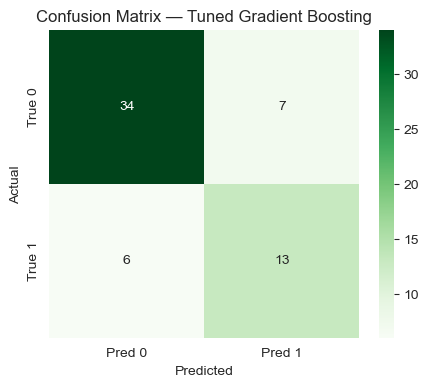

In [33]:
# Confusion matrix of the final tuned model
cm_tuned = confusion_matrix(y_test, y_pred_tuned)

plt.figure(figsize=(5, 4))
sns.heatmap(cm_tuned, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Pred 0', 'Pred 1'], yticklabels=['True 0', 'True 1'])
plt.title(f'Confusion Matrix — Tuned {best_model_name}')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

In [34]:
before_after = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score'],
    f'{best_model_name} (Before Tuning)': [
        results_df[results_df.Model == best_model_name]['Accuracy'].values[0],
        results_df[results_df.Model == best_model_name]['Precision'].values[0],
        results_df[results_df.Model == best_model_name]['Recall'].values[0],
        results_df[results_df.Model == best_model_name]['F1-Score'].values[0],
    ],
    f'{best_model_name} (After Tuning)': [tuned_acc, tuned_prec, tuned_rec, tuned_f1]
})
before_after

,Metric,Gradient Boosting (Before Tuning),Gradient Boosting (After Tuning)
0,Accuracy,0.800000,0.783333
1,Precision,0.666667,0.650000
2,Recall,0.736842,0.684211
3,F1-Score,0.700000,0.666667
